<a href="https://colab.research.google.com/github/kaylabiwott/NGOConnect_MLEngine/blob/main/Airplane_Crashes_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Airplane_Crashes_and_Fatalities_Since_1908.csv to Airplane_Crashes_and_Fatalities_Since_1908.csv


In [2]:
import pandas as pd

df = pd.read_csv(next(iter(uploaded)))

df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


## Question 1: Download and Upload the Dataset

The Airplane Crashes Dataset was downloaded from Kaggle and uploaded into the Google Colab notebook for analysis.

## Question 2: Number of Rows and Columns

Determine the number of rows and columns in the dataset.

In [3]:
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 5268
Number of columns: 13


## Question 3: Display the Last 75 Rows

Display the last 75 rows of the dataset.

In [4]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


## Question 4: Treatment of Missing Data

Determine the most appropriate method for treating the missing data in each column and justify the choice based on the type and meaning of the data.

In [5]:
missing_values = df.isnull().sum()

print(missing_values)

Date               0
Time            2219
Location          20
Operator          18
Flight #        4199
Route           1707
Type              27
Registration     335
cn/In           1228
Aboard            22
Fatalities        12
Ground            22
Summary          390
dtype: int64


In [6]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': missing_percentage
})

missing_summary

,Missing Values,Missing Percentage
Date,0,0.000000
Time,2219,42.122248
Location,20,0.379651
Operator,18,0.341686
Flight #,4199,79.707669
Route,1707,32.403189
Type,27,0.512528
Registration,335,6.359150
cn/In,1228,23.310554
Aboard,22,0.417616


In [8]:
print(df.columns.tolist())

['Date', 'Time', 'Location', 'Operator', 'Flight #', 'Route', 'Type', 'Registration', 'cn/In', 'Aboard', 'Fatalities', 'Ground', 'Summary']


### Treatment Methods and Justification

| Column | Recommended Treatment | Justification |
|---|---|---|
| Date | Retain as missing or investigate the original source | Date is a time variable. Replacing a missing date with a mean or median would create a potentially false date. |
| Time | Mode or "Unknown" | Time is a categorical/time variable. A numerical mean is not appropriate, and missing values can be represented by the most common time or "Unknown". |
| Location | "Unknown" or mode | Location is categorical. A mean or median cannot be calculated for location. |
| Operator | Mode or "Unknown" | Operator is categorical. The most frequent operator can be used when appropriate, or missing values can be labelled "Unknown". |
| Flight # | "Unknown" | Flight number is an identifier. Numerical mean or median imputation would not produce a meaningful flight number. |
| Route | "Unknown" or mode | Route is categorical. It cannot be meaningfully replaced using a numerical statistic. |
| Type | Mode | Aircraft type is categorical, so the most frequent aircraft type is an appropriate imputation where imputation is necessary. |
| Registration | "Unknown" | Aircraft registration is an identifier. Assigning a mean or median would be meaningless. |
| cn/In | Median or "Unknown", depending on its interpretation | Where treated as numerical aircraft information, the median is preferable because it is less affected by extreme values. If it is treated as an identifier, "Unknown" is more appropriate. |
| Aboard | Median | Aboard is a numerical count. The median is less affected by unusually large crashes than the mean. |
| Fatalities | Median, where imputation is necessary | Fatalities is a numerical count and the median is more resistant to extreme values. |
| Ground | Median or 0 where missing clearly means no ground fatalities | Ground represents a numerical count of fatalities on the ground. The appropriate choice depends on whether missing means unknown or actually zero. |
| Summary | "Unknown" or leave missing | Summary is free-text data, so it cannot be meaningfully replaced with a mean or median. |

In [9]:
df.isnull().sum()

,0
Date,0
Time,2219
Location,20
Operator,18
Flight #,4199
Route,1707
Type,27
Registration,335
cn/In,1228
Aboard,22


### Appropriate Methods for Treating Missing Data

| Column | Missing Values | Recommended Treatment | Justification |
|---|---:|---|---|
| Date | 0 | No treatment required | There are no missing Date values. |
| Time | 2219 | Mode or "Unknown" | Time is a categorical/time variable. A numerical mean or median would not be appropriate. |
| Location | 20 | "Unknown" or mode | Location is categorical, so it cannot be meaningfully replaced using a numerical statistic. |
| Operator | 18 | Mode or "Unknown" | Operator is categorical. The most frequent operator can be used where appropriate, or missing values can be labelled "Unknown". |
| Flight # | 4199 | "Unknown" | Flight # is an identifier. Using a mean or median would not produce a meaningful flight number. |
| Route | 1707 | "Unknown" or mode | Route is categorical and cannot be meaningfully calculated using a numerical average. |
| Type | 27 | Mode | Aircraft type is categorical, so the most frequently occurring type is an appropriate choice when imputation is necessary. |
| Registration | 335 | "Unknown" | Registration is an identifier, so numerical imputation would be inappropriate. |
| cn/In | 1228 | Median or "Unknown" | If treated as numerical information, the median is preferable because it is less affected by extreme values. If treated as an identifier, "Unknown" is appropriate. |
| Aboard | 22 | Median | Aboard is a numerical count. The median is less affected by unusually large values than the mean. |
| Fatalities | 12 | Median, if imputation is necessary | Fatalities is numerical count data, and the median is less affected by extreme crash values. |
| Ground | 22 | Median or 0 where justified | Ground is a numerical count. Zero is appropriate only when the missing value can reliably be interpreted as no ground fatalities; otherwise, median imputation may be used. |
| Summary | 390 | "Unknown" or leave missing | Summary contains text, so a numerical mean or median cannot be used. |

## Question 5: Create the fatality_locations DataFrame

Create a new dataframe from the raw/uncleaned dataset called `fatality_locations` containing the columns Date, Location, Aboard, and Fatalities.

In [10]:
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']].copy()

fatality_locations

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0
...,...,...,...,...
5263,05/20/2009,"Near Madiun, Indonesia",112.0,98.0
5264,05/26/2009,"Near Isiro, DemocratiRepubliCongo",4.0,4.0
5265,06/01/2009,"AtlantiOcean, 570 miles northeast of Natal, Br...",228.0,228.0
5266,06/07/2009,"Near Port Hope Simpson, Newfoundland, Canada",1.0,1.0


In [11]:
print(fatality_locations.columns.tolist())

['Date', 'Location', 'Aboard', 'Fatalities']


## Question 6: Date with the Highest Number of Fatalities

Determine the date of the crash with the highest recorded number of fatalities.

In [12]:
highest_fatalities = fatality_locations['Fatalities'].max()

print("Highest number of fatalities:", highest_fatalities)

Highest number of fatalities: 583.0


In [13]:
result = fatality_locations[
    fatality_locations['Fatalities'] == highest_fatalities
]

print(result[['Date', 'Fatalities']])

            Date  Fatalities
2963  03/27/1977       583.0


In [14]:
print("Date with the highest recorded fatalities:")
print(result['Date'].to_string(index=False))

print("\nNumber of fatalities:")
print(int(highest_fatalities))

Date with the highest recorded fatalities:
03/27/1977

Number of fatalities:
583


## Question 7: Aboard Compared with Fatalities

Compare the number of people aboard with the number of fatalities per crash and determine whether there were any recorded crashes with zero fatalities.

In [15]:
fatality_locations[['Aboard', 'Fatalities']].describe()

,Aboard,Fatalities
count,5246.000000,5256.000000
mean,27.554518,20.068303
std,43.076711,33.199952
min,0.000000,0.000000
25%,5.000000,3.000000
50%,13.000000,9.000000
75%,30.000000,23.000000
max,644.000000,583.000000


In [16]:
zero_fatality_crashes = fatality_locations[
    fatality_locations['Fatalities'] == 0
]

print("Number of crashes with no fatalities:", len(zero_fatality_crashes))

Number of crashes with no fatalities: 58


In [17]:
zero_fatality_crashes

,Date,Location,Aboard,Fatalities
108,10/21/1926,English Channel,12.0,0.0
387,03/05/1936,"Near Tengya, China",6.0,0.0
889,10/08/1947,"Near El Paso, Texas",54.0,0.0
897,11/11/1947,"Gallup, New Mexico",25.0,0.0
1265,05/25/1953,"Amsterdam, Netherlands",34.0,0.0
1359,01/19/1955,"Des Moines, Iowa",39.0,0.0
1440,09/09/1956,"Bartlesville, Oklahoma",18.0,0.0
1443,10/16/1956,Over the PacifiOcean,31.0,0.0
1610,06/30/1959,"Ishikawa City, Ryukyu Island, Okinawa",1.0,0.0
1837,02/28/1963,"Boston, Massachusetts",26.0,0.0


## Question 8: Split the Location Column

Split the Location column into two separate columns: Region and State/Country.

In [18]:
fatality_locations['Location'].head(20)

,Location
0,"Fort Myer, Virginia"
1,"AtlantiCity, New Jersey"
2,"Victoria, British Columbia, Canada"
3,Over the North Sea
4,"Near Johannisthal, Germany"
5,"Tienen, Belgium"
6,"Off Cuxhaven, Germany"
7,"Near Jambol, Bulgeria"
8,"Billericay, England"
9,"Potters Bar, England"


In [21]:
fatality_locations[['Region', 'State/Country']] = (
    fatality_locations['Location']
    .str.split(',', n=1, expand=True)
)

In [22]:
fatality_locations['Region'] = fatality_locations['Region'].str.strip()
fatality_locations['State/Country'] = fatality_locations['State/Country'].str.strip()

In [23]:
fatality_locations.head(20)

,Date,Location,Aboard,Fatalities,Region,State/Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,Victoria,"British Columbia, Canada"
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany
5,03/05/1915,"Tienen, Belgium",41.0,21.0,Tienen,Belgium
6,09/03/1915,"Off Cuxhaven, Germany",19.0,19.0,Off Cuxhaven,Germany
7,07/28/1916,"Near Jambol, Bulgeria",20.0,20.0,Near Jambol,Bulgeria
8,09/24/1916,"Billericay, England",22.0,22.0,Billericay,England
9,10/01/1916,"Potters Bar, England",19.0,19.0,Potters Bar,England


## Question 9: Top 100 Crashes by Fatalities

Order the dataframe by fatalities from highest to lowest and select the first 100 records.

In [24]:
top_100 = (
    fatality_locations
    .sort_values(by='Fatalities', ascending=False)
    .head(100)
)

top_100

,Date,Location,Aboard,Fatalities,Region,State/Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,Mt. Osutaka,"near Ueno Village, Japan"
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,Elburz Mtns.,"near Laskarak, Markazi, Iran"
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


In [25]:
print("Number of records:", len(top_100))

Number of records: 100


## Question 10: Distribution of the Top 25 Fatalities by Country/U.S. State

Generate a pie chart showing the distribution of the top 25 fatalities by country/U.S. State.

In [29]:
fatality_locations['Fatalities'] = pd.to_numeric(
    fatality_locations['Fatalities'],
    errors='coerce'
)

chart_data = fatality_locations.dropna(
    subset=['State/Country', 'Fatalities']
)

top_25 = (
    chart_data
    .groupby('State/Country')['Fatalities']
    .sum()
    .sort_values(ascending=False)
    .head(25)
)

top_25

,Fatalities
State/Country,
Russia,6350.0
Brazil,2938.0
Colombia,2624.0
India,2211.0
France,2017.0
Indonesia,1818.0
California,1691.0
China,1577.0
Peru,1380.0


In [31]:
import matplotlib.pyplot as plt

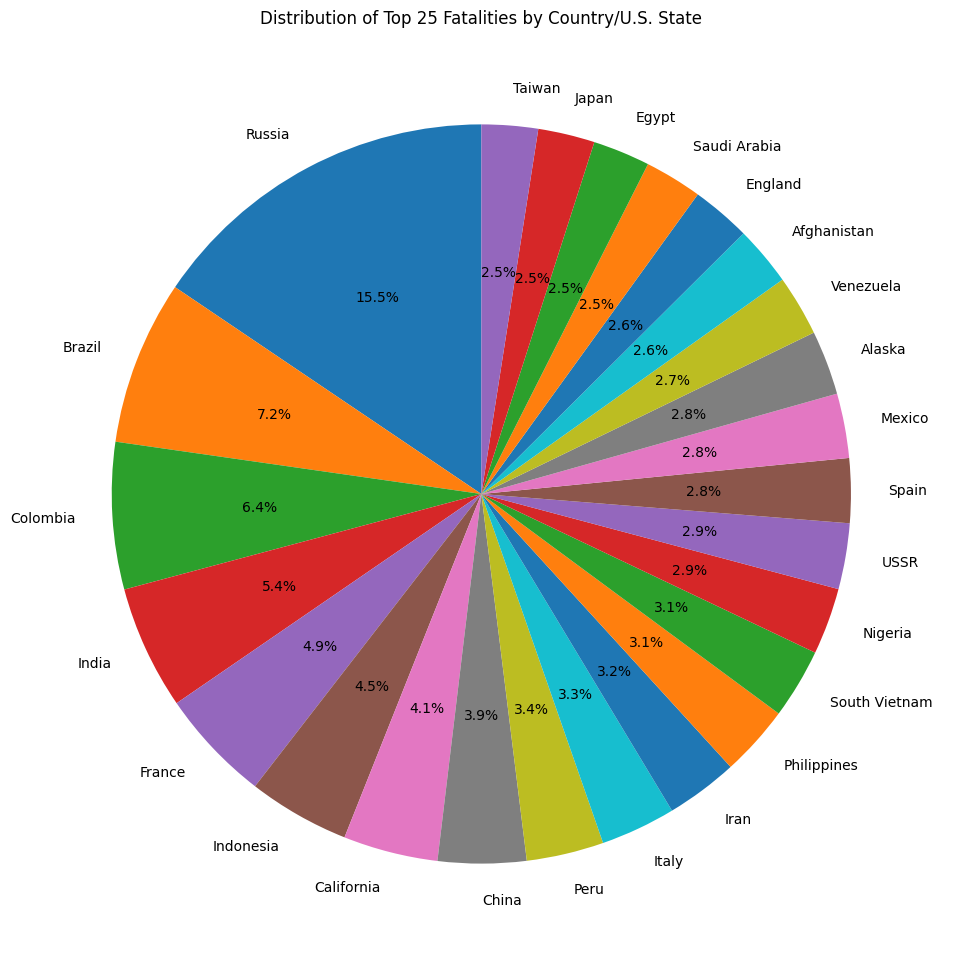

In [32]:
plt.figure(figsize=(12, 12))

plt.pie(
    top_25,
    labels=top_25.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Top 25 Fatalities by Country/U.S. State')

plt.show()